# Exploratory Data Analysis — Visualization

**IBM Data Science Capstone — SpaceX Falcon 9**

Repository: [https://github.com/MCerros/IBM-Data-Science-Capstone-SpaceX](https://github.com/MCerros/IBM-Data-Science-Capstone-SpaceX)

Direct notebook URL after upload:  
[https://github.com/MCerros/IBM-Data-Science-Capstone-SpaceX/blob/main/04_SpaceX_EDA_Visualization.ipynb](https://github.com/MCerros/IBM-Data-Science-Capstone-SpaceX/blob/main/04_SpaceX_EDA_Visualization.ipynb)

**Data integrity note:** This notebook uses the project CSV files stored in the same repository.
No rows, metrics, charts, or model scores are manually invented.

## Objective

Examine relationships between flight number, payload mass, launch site, orbit,
year, and first-stage landing success.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("dataset_part_2.csv")
data["Date"] = pd.to_datetime(data["Date"])
data["Year"] = data["Date"].dt.year

print("Dataset shape:", data.shape)
print(f"Overall landing success rate: {data['Class'].mean():.2%}")

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-y6rj_fbu because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Dataset shape: (90, 19)
Overall landing success rate: 66.67%


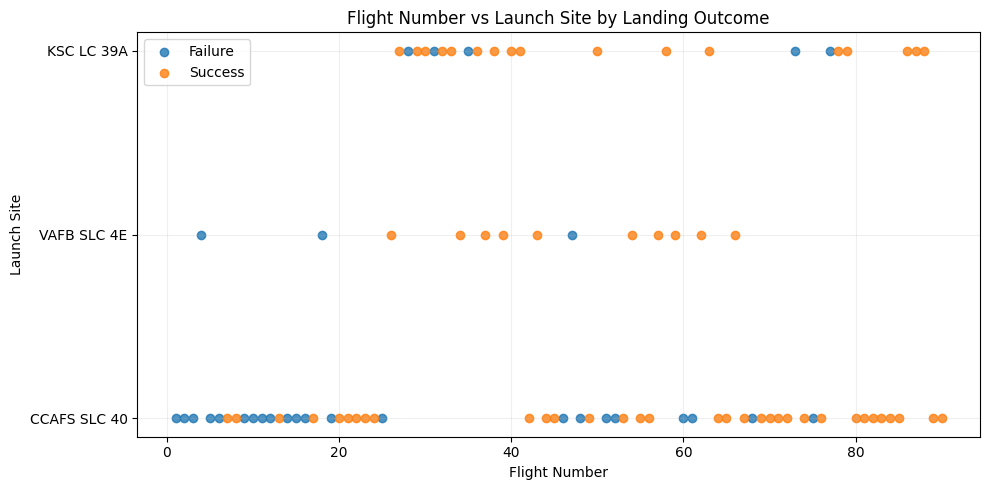

In [2]:
site_order = list(data["LaunchSite"].dropna().unique())
site_y = {site: i for i, site in enumerate(site_order)}

fig, ax = plt.subplots(figsize=(10, 5))
for cls, label in [(0, "Failure"), (1, "Success")]:
    sub = data[data["Class"] == cls]
    ax.scatter(sub["FlightNumber"], sub["LaunchSite"].map(site_y), label=label, alpha=0.8)
ax.set_yticks(range(len(site_order)))
ax.set_yticklabels(site_order)
ax.set_xlabel("Flight Number")
ax.set_ylabel("Launch Site")
ax.set_title("Flight Number vs Launch Site by Landing Outcome")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

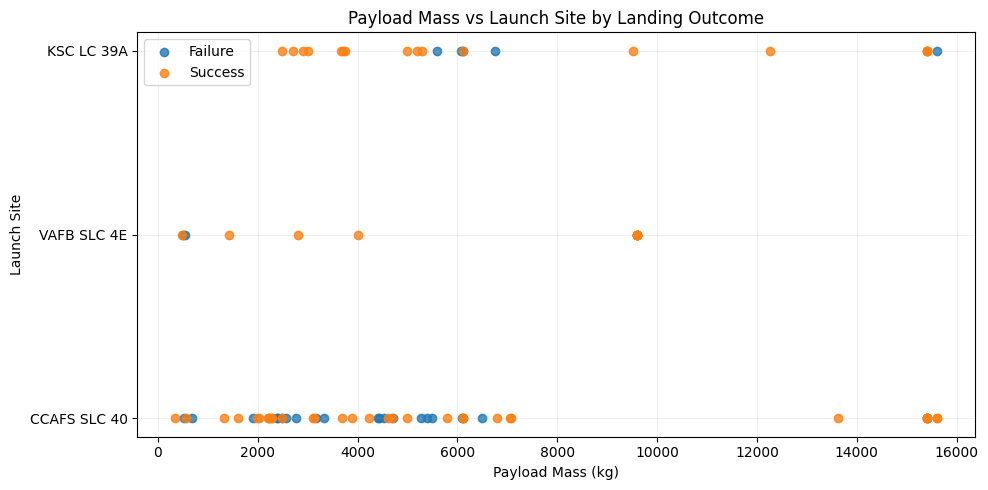

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
for cls, label in [(0, "Failure"), (1, "Success")]:
    sub = data[data["Class"] == cls]
    ax.scatter(sub["PayloadMass"], sub["LaunchSite"].map(site_y), label=label, alpha=0.8)
ax.set_yticks(range(len(site_order)))
ax.set_yticklabels(site_order)
ax.set_xlabel("Payload Mass (kg)")
ax.set_ylabel("Launch Site")
ax.set_title("Payload Mass vs Launch Site by Landing Outcome")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

,Launches,SuccessRate
Orbit,,
ES-L1,1,1.000000
GEO,1,1.000000
HEO,1,1.000000
SSO,5,1.000000
VLEO,14,0.857143
LEO,7,0.714286
PO,9,0.666667
MEO,3,0.666667
ISS,21,0.619048


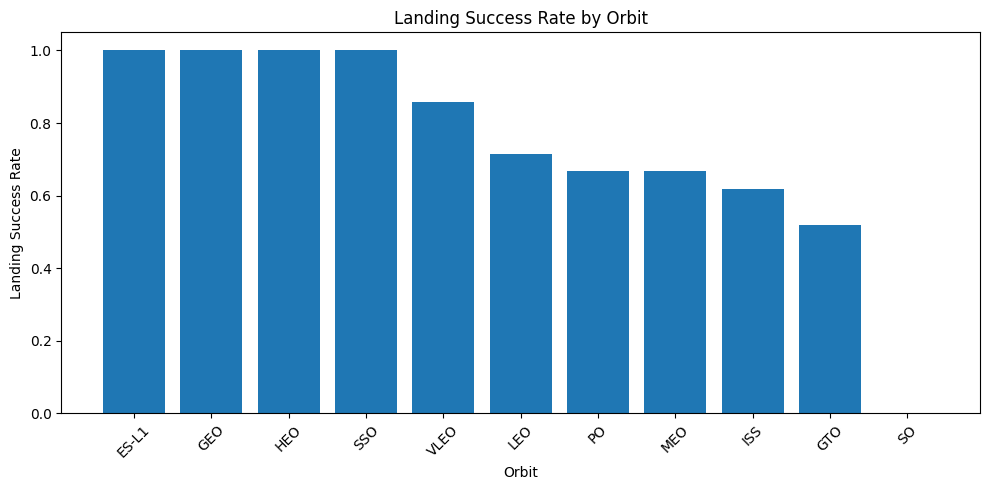

In [4]:
orbit_success = (
    data.groupby("Orbit")["Class"]
    .agg(["count", "mean"])
    .rename(columns={"count": "Launches", "mean": "SuccessRate"})
    .sort_values("SuccessRate", ascending=False)
)
display(orbit_success)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(orbit_success.index, orbit_success["SuccessRate"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("Landing Success Rate")
ax.set_xlabel("Orbit")
ax.set_title("Landing Success Rate by Orbit")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

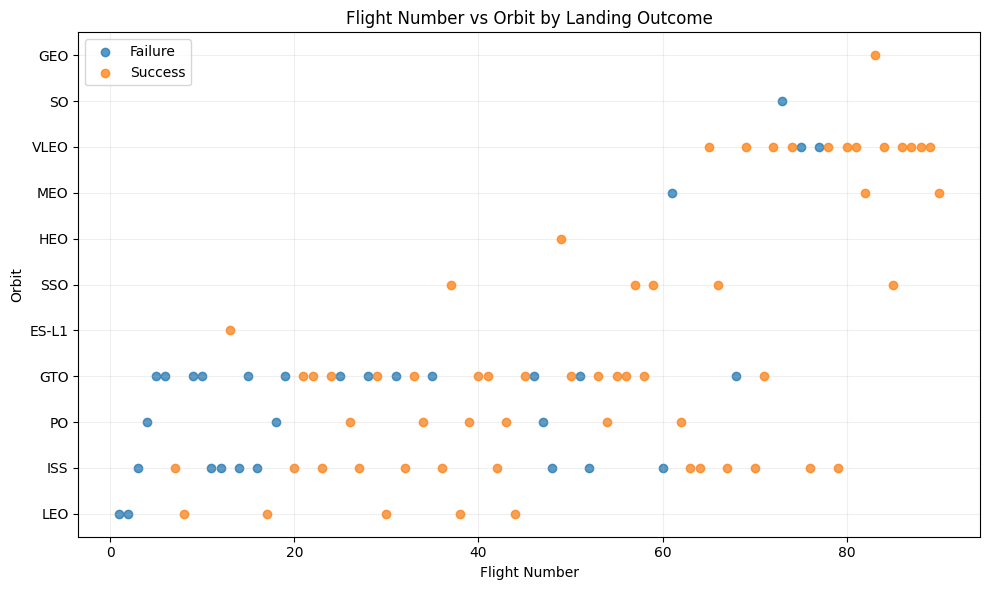

In [5]:
orbit_order = list(data["Orbit"].dropna().unique())
orbit_y = {orbit: i for i, orbit in enumerate(orbit_order)}

fig, ax = plt.subplots(figsize=(10, 6))
for cls, label in [(0, "Failure"), (1, "Success")]:
    sub = data[data["Class"] == cls]
    ax.scatter(sub["FlightNumber"], sub["Orbit"].map(orbit_y), label=label, alpha=0.75)
ax.set_yticks(range(len(orbit_order)))
ax.set_yticklabels(orbit_order)
ax.set_xlabel("Flight Number")
ax.set_ylabel("Orbit")
ax.set_title("Flight Number vs Orbit by Landing Outcome")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

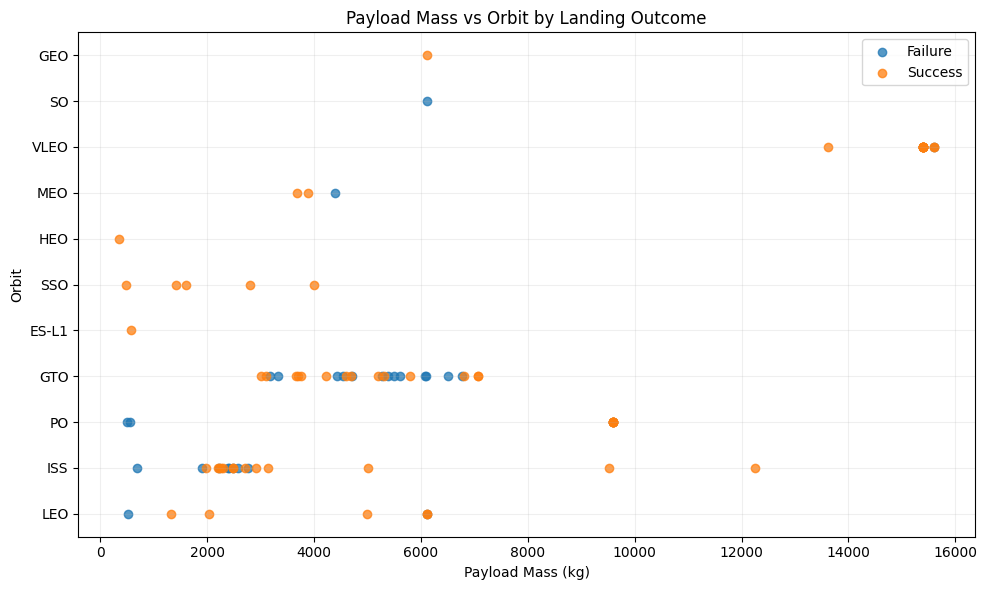

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
for cls, label in [(0, "Failure"), (1, "Success")]:
    sub = data[data["Class"] == cls]
    ax.scatter(sub["PayloadMass"], sub["Orbit"].map(orbit_y), label=label, alpha=0.75)
ax.set_yticks(range(len(orbit_order)))
ax.set_yticklabels(orbit_order)
ax.set_xlabel("Payload Mass (kg)")
ax.set_ylabel("Orbit")
ax.set_title("Payload Mass vs Orbit by Landing Outcome")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

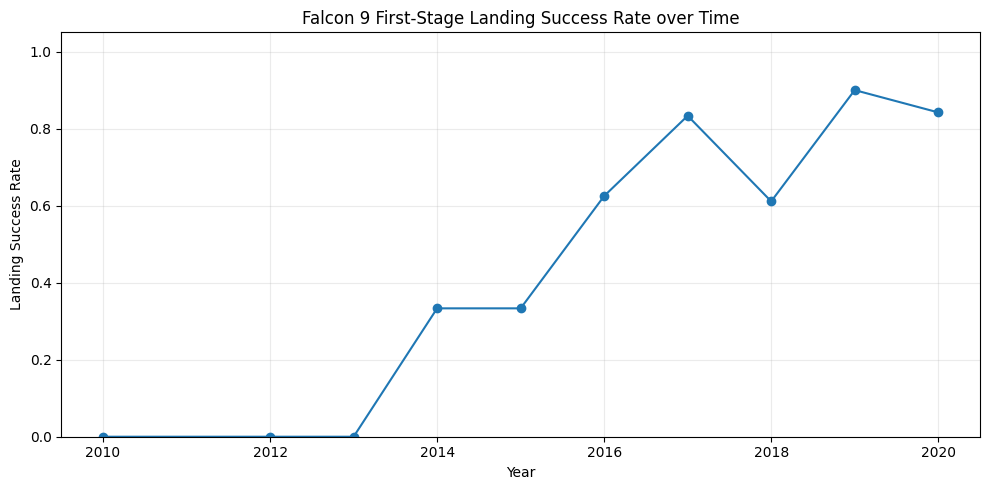

,SuccessRate
Year,
2010,0.000000
2012,0.000000
2013,0.000000
2014,0.333333
2015,0.333333
2016,0.625000
2017,0.833333
2018,0.611111
2019,0.900000


In [7]:
yearly = data.groupby("Year")["Class"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yearly.index, yearly.values, marker="o")
ax.set_ylim(0, 1.05)
ax.set_xlabel("Year")
ax.set_ylabel("Landing Success Rate")
ax.set_title("Falcon 9 First-Stage Landing Success Rate over Time")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

display(yearly.rename("SuccessRate").to_frame())

,Launches,Successes,SuccessRate
LaunchSite,,,
KSC LC 39A,22,17,0.772727
VAFB SLC 4E,13,10,0.769231
CCAFS SLC 40,55,33,0.600000


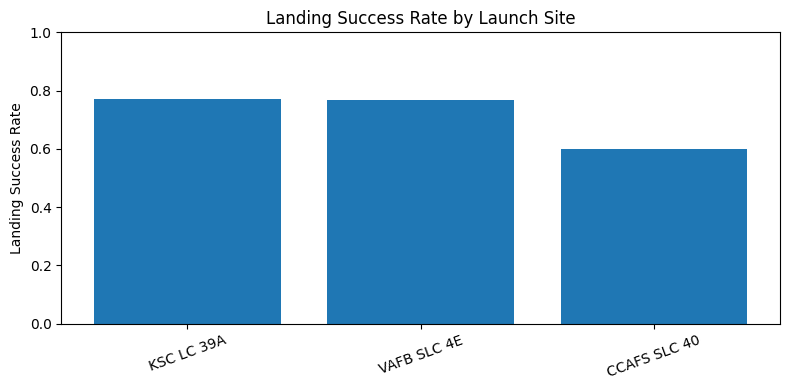

In [8]:
site_success = (
    data.groupby("LaunchSite")["Class"]
    .agg(["count", "sum", "mean"])
    .rename(columns={"count": "Launches", "sum": "Successes", "mean": "SuccessRate"})
    .sort_values("SuccessRate", ascending=False)
)
display(site_success)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(site_success.index, site_success["SuccessRate"])
ax.set_ylim(0, 1)
ax.set_ylabel("Landing Success Rate")
ax.set_title("Landing Success Rate by Launch Site")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

In [9]:
print("Payload mass / landing outcome Pearson correlation:")
print(data[["PayloadMass", "Class"]].corr().loc["PayloadMass", "Class"])

Payload mass / landing outcome Pearson correlation:
0.19999156938502707
